# 03 · Synthetic validation against Chang & Hanssen Fig. 4

**Objective:** Simulate the paper's synthetic example (linear + thermal + Heaviside offset, Section IV-A) with known ground truth, run the full DIA loop, and check that H6 wins and the recovered parameters are close to the simulated ones. Do this BEFORE trusting the pipeline on real EGMS data.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from insar_mht import library, hypotheses, testing, dia, rpn, unwrap, reliability
from insar_mht.io import egms


Text(0.5, 1.0, 'Synthetic H6 case: linear + thermal + Heaviside step (Fig. 4 setup)')

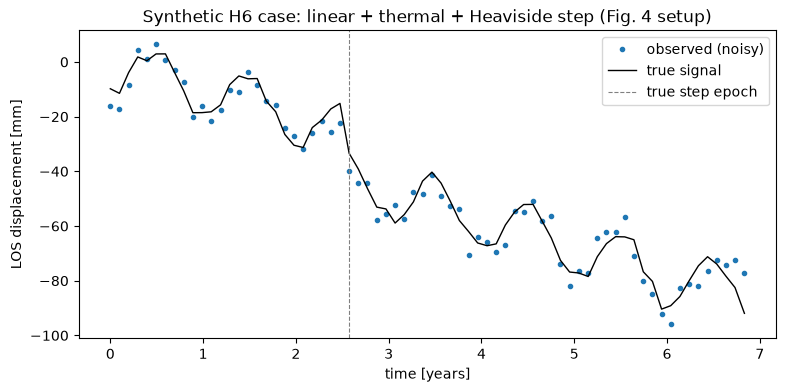

In [2]:
rng = np.random.default_rng(42)

# 70 Envisat-like acquisitions, Dec 2003 to Oct 2010 (Section IV-A)
dates = pd.date_range("2003-12-01", "2010-10-01", periods=70)
t = (dates - dates[0]).days.to_numpy() / 365.25

# Synthetic temperature record (real Envisat/Rotterdam records not available here):
# seasonal sinusoid + noise, phased so t=0 (Dec) is near the cold half of the cycle.
delta_temp = 8.0 * np.sin(2 * np.pi * t - np.pi / 2) + rng.normal(0, 1.5, size=len(t))

TRUE_V = -10.0        # mm/yr
TRUE_ETA = 1.3         # mm/K (paper reports 1.3e-3 m/K, same number, different unit)
TRUE_STEP_INDEX = 26
TRUE_DELTA = -18.0     # mm, step at epoch 26
NOISE_STD = 5.0        # mm

step_col = library.m6_heaviside_step(len(t), TRUE_STEP_INDEX)
y_true = TRUE_V * t + TRUE_ETA * delta_temp + TRUE_DELTA * step_col
y = y_true + rng.normal(0, NOISE_STD, size=len(t))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, y, ".", label="observed (noisy)")
ax.plot(t, y_true, "-", label="true signal", color="k", lw=1)
ax.axvline(t[TRUE_STEP_INDEX], color="gray", ls="--", lw=0.8, label="true step epoch")
ax.set_xlabel("time [years]"); ax.set_ylabel("LOS displacement [mm]"); ax.legend()
ax.set_title("Synthetic H6 case: linear + thermal + Heaviside step (Fig. 4 setup)")

In [3]:
from scipy import stats

A0 = library.design_matrix_h0(t)
sigma = NOISE_STD
Qyy = (sigma ** 2) * np.eye(len(t))
Qyy_inv = np.linalg.inv(Qyy)

h0_fit = testing.gls_fit(y, A0, Qyy_inv)
alpha0 = 1 / (2 * len(t))
q0 = len(t) - A0.shape[1]
T0 = testing.omt_statistic(h0_fit.e_hat, Qyy_inv)
K = stats.chi2.ppf(1 - alpha0, q0)
print(f"T0={T0:.1f}, K={K:.1f} -> {'REJECTED' if T0 > K else 'sustained'} (should be REJECTED)")

T0=274.4, K=101.1 -> REJECTED (should be REJECTED)


In [4]:
# Full Table I library (H1-H4 plus per-epoch step search for H5-H7): ~200+ hypotheses for m=70
library_hyps = hypotheses.table_i_hypotheses(t, delta_temp, beta_grid=[0.1, 0.25, 0.5, 1.0])
print(f"{len(library_hyps)} candidate hypotheses")

gamma0 = 0.5
lambda0 = testing.noncentrality_from_power(gamma0, alpha0, q=1)

precomputed = [
    dia.precompute_hypothesis_class(h, Qyy_inv, h0_fit.q_ehat_ehat, lambda0, gamma0) for h in library_hyps
]

424 candidate hypotheses


In [5]:
result = dia.run_dia(y, A0, Qyy, precomputed, alpha0)

ranked = sorted(result.all_ratios.items(), key=lambda kv: kv[1], reverse=True)
print("top 5 hypotheses by test ratio:")
for name, ratio in ranked[:5]:
    print(f"  {ratio:6.2f}  {name}")

print()
print(f"winner: {result.best_hypothesis.name}  (ratio={result.best_ratio:.2f})")
print(f"expected: a 'H6_thermal+step@{TRUE_STEP_INDEX}'-shaped hypothesis")

top 5 hypotheses by test ratio:
   26.16  H6_thermal+step@26
   25.78  H6_thermal+step@25
   25.71  H6_thermal+step@24
   24.26  H6_thermal+step@23
   23.59  H6_thermal+step@27

winner: H6_thermal+step@26  (ratio=26.16)
expected: a 'H6_thermal+step@26'-shaped hypothesis


                 true  estimated
v              -10.00      -9.75  mm/yr
eta              1.30       1.23  mm/K
Delta          -18.00     -19.41  mm


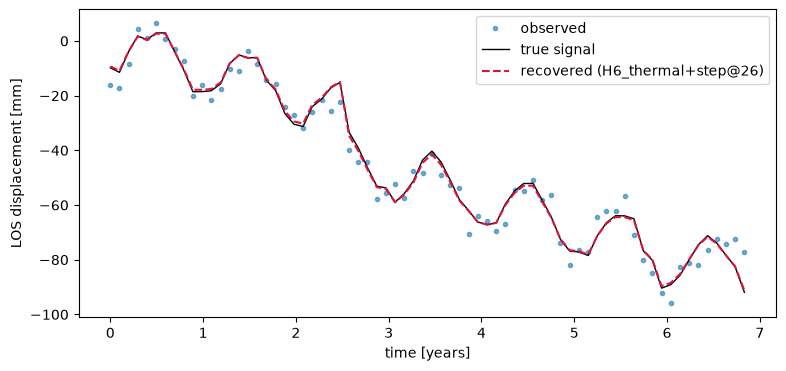

In [6]:
v_hat, eta_hat, delta_hat = result.best_fit.x_hat
print(f"{'':10s} {'true':>10s} {'estimated':>10s}")
print(f"{'v':10s} {TRUE_V:10.2f} {v_hat:10.2f}  mm/yr")
print(f"{'eta':10s} {TRUE_ETA:10.2f} {eta_hat:10.2f}  mm/K")
print(f"{'Delta':10s} {TRUE_DELTA:10.2f} {delta_hat:10.2f}  mm")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, y, ".", label="observed", alpha=0.6)
ax.plot(t, y_true, "-", color="k", lw=1, label="true signal")
ax.plot(t, result.best_fit.y_hat, "--", color="crimson", label=f"recovered ({result.best_hypothesis.name})")
ax.set_xlabel("time [years]"); ax.set_ylabel("LOS displacement [mm]"); ax.legend()